# PaySim Initial Dataset Inspection

## Purpose

This notebook performs the initial inspection of the PaySim synthetic financial transaction dataset used in the Fraud Detection System internship project.

The purpose of this stage is to understand the structure, variables, data types, completeness, transaction categories, and fraud distribution before performing any data cleaning, transformation, feature engineering, or machine-learning modelling.

## Methodology Stage

This notebook belongs to the **Prepare** stage of the project's analytical methodology:

**Ask → Prepare → Process → Analyze → Share → Act**

## Dataset

The project uses one primary dataset:

**PaySim — Synthetic Financial Dataset for Fraud Detection**

The dataset contains simulated financial transactions and includes a binary fraud indicator (`isFraud`).

## Important Principle

No records or variables will be removed during this initial inspection.

Potential data-quality problems, leakage risks, outliers, and unsuitable variables will be documented first and addressed during the **Process** stage.

In [4]:
import pandas as pd

In [5]:
DATA_PATH = "../data/raw/PS_20174392719_1491204439457_log.csv"

print(DATA_PATH)

../data/raw/PS_20174392719_1491204439457_log.csv


In [6]:
df_sample = pd.read_csv(DATA_PATH, nrows=10000)

print("Rows loaded:", len(df_sample))
print("Columns:", len(df_sample.columns))

Rows loaded: 10000
Columns: 11


In [7]:
print(df_sample.columns.tolist())

['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


In [8]:
df_sample.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [9]:
df_sample.describe(include="all")

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,10000.000000,10000,1.000000e+04,10000,1.000000e+04,1.000000e+04,10000,1.000000e+04,1.000000e+04,10000.000000,10000.0
unique,NaN,5,NaN,10000,NaN,NaN,6397,NaN,NaN,NaN,NaN
top,NaN,PAYMENT,NaN,C1231006815,NaN,NaN,C985934102,NaN,NaN,NaN,NaN
freq,NaN,5465,NaN,1,NaN,NaN,62,NaN,NaN,NaN,NaN
mean,4.178900,NaN,1.035467e+05,NaN,8.939330e+05,9.152741e+05,NaN,9.342758e+05,1.096606e+06,0.006800,0.0
std,2.479821,NaN,2.663072e+05,NaN,2.135683e+06,2.181428e+06,NaN,2.676340e+06,3.014496e+06,0.082185,0.0
min,1.000000,NaN,2.390000e+00,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000,0.0
25%,1.000000,NaN,4.397530e+03,NaN,1.276875e+02,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000,0.0
50%,5.000000,NaN,1.285874e+04,NaN,2.137556e+04,1.034994e+04,NaN,0.000000e+00,0.000000e+00,0.000000,0.0
75%,7.000000,NaN,1.143825e+05,NaN,1.782719e+05,1.760934e+05,NaN,2.831067e+05,2.520552e+05,0.000000,0.0


In [10]:
missing_values = df_sample.isnull().sum()

print(missing_values)

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [11]:
duplicate_count = df_sample.duplicated().sum()

print("Duplicate rows in sample:", duplicate_count)

Duplicate rows in sample: 0


In [12]:
print(df_sample["type"].value_counts())

type
PAYMENT     5465
CASH_IN     1949
CASH_OUT    1321
TRANSFER     921
DEBIT        344
Name: count, dtype: int64


In [13]:
df_sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            10000 non-null  int64  
 1   type            10000 non-null  str    
 2   amount          10000 non-null  float64
 3   nameOrig        10000 non-null  str    
 4   oldbalanceOrg   10000 non-null  float64
 5   newbalanceOrig  10000 non-null  float64
 6   nameDest        10000 non-null  str    
 7   oldbalanceDest  10000 non-null  float64
 8   newbalanceDest  10000 non-null  float64
 9   isFraud         10000 non-null  int64  
 10  isFlaggedFraud  10000 non-null  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 859.5 KB


## Initial Dataset Structure

The initial sample contains 10,000 transactions and 11 variables.

The dataset contains:

- Numerical variables representing transaction amounts, balances, time steps, and fraud indicators.
- Categorical data representing transaction type.
- Account identifiers representing transaction participants.
- A binary target variable indicating whether a transaction is fraudulent.
- An existing fraud-flag indicator.

The initial sample contains no missing values.

In [14]:
fraud_counts = df_sample["isFraud"].value_counts()

print(fraud_counts)

isFraud
0    9932
1      68
Name: count, dtype: int64


In [15]:
fraud_percentages = df_sample["isFraud"].value_counts(normalize=True) * 100

print(fraud_percentages)

isFraud
0    99.32
1     0.68
Name: proportion, dtype: float64


In [16]:
print(df_sample["isFlaggedFraud"].value_counts())

isFlaggedFraud
0    10000
Name: count, dtype: int64


In [17]:
transaction_types = df_sample["type"].value_counts()

print(transaction_types)

type
PAYMENT     5465
CASH_IN     1949
CASH_OUT    1321
TRANSFER     921
DEBIT        344
Name: count, dtype: int64


<Axes: title={'center': 'Transaction Types in Initial Sample'}, xlabel='Transaction Type', ylabel='Number of Transactions'>

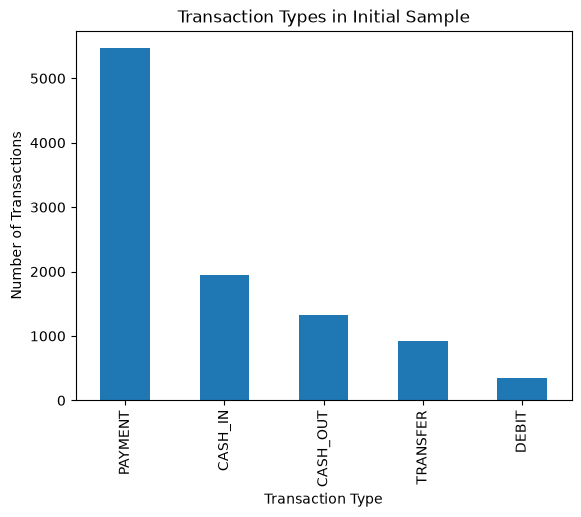

In [18]:
transaction_types.plot(
    kind="bar",
    title="Transaction Types in Initial Sample",
    xlabel="Transaction Type",
    ylabel="Number of Transactions"
)

<Axes: title={'center': 'Fraud vs Legitimate Transactions'}, xlabel='Fraud Indicator', ylabel='Number of Transactions'>

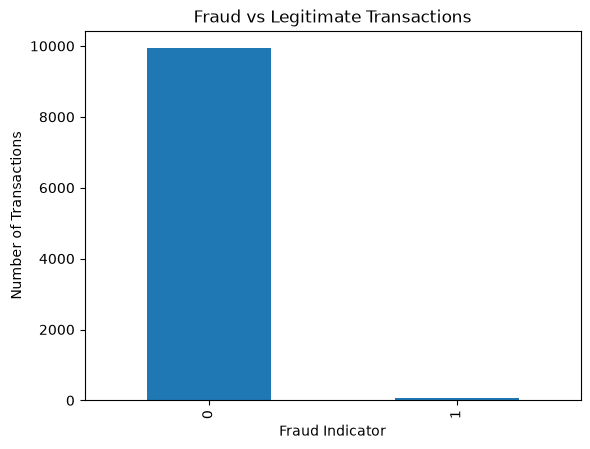

In [19]:
fraud_counts.plot(
    kind="bar",
    title="Fraud vs Legitimate Transactions",
    xlabel="Fraud Indicator",
    ylabel="Number of Transactions"
)

In [20]:
pd.crosstab(
    df_sample["isFraud"],
    df_sample["isFlaggedFraud"],
    margins=True
)

isFlaggedFraud,0,All
isFraud,,
0,9932,9932
1,68,68
All,10000,10000


In [21]:
print("Minimum amount:", df_sample["amount"].min())
print("Maximum amount:", df_sample["amount"].max())
print("Average amount:", df_sample["amount"].mean())
print("Median amount:", df_sample["amount"].median())

Minimum amount: 2.39
Maximum amount: 10000000.0
Average amount: 103546.689949
Median amount: 12858.740000000002


<Axes: title={'center': 'Transaction Amount Distribution'}, xlabel='Transaction Amount', ylabel='Frequency'>

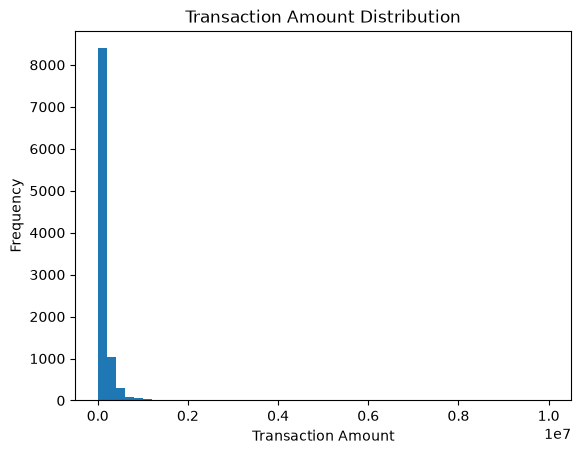

In [22]:
df_sample["amount"].plot(
    kind="hist",
    bins=50,
    title="Transaction Amount Distribution",
    xlabel="Transaction Amount"
)

In [23]:
print("Minimum step:", df_sample["step"].min())
print("Maximum step:", df_sample["step"].max())
print("Unique steps:", df_sample["step"].nunique())

Minimum step: 1
Maximum step: 7
Unique steps: 7


In [24]:
df_sample["step"].value_counts().sort_index().head(20)

step
1    2708
2    1014
3     552
4     565
5     665
6    1660
7    2836
Name: count, dtype: int64

In [25]:
print("Unique origin accounts:", df_sample["nameOrig"].nunique())
print("Unique destination accounts:", df_sample["nameDest"].nunique())

Unique origin accounts: 10000
Unique destination accounts: 6397


## Full Dataset Inspection

The initial inspection was performed using a 10,000-row sample to establish the dataset structure without unnecessarily loading the complete file.

The following analysis loads the complete dataset to establish definitive dataset-level statistics before data processing begins.

In [26]:
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Dataset loaded successfully.
Rows: 6362620
Columns: 11


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [28]:
missing_values = df.isnull().sum()

print("Missing values by column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values by column:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Total missing values: 0


In [29]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [30]:
fraud_counts = df["isFraud"].value_counts()

print("Fraud class distribution:")
print(fraud_counts)

print("\nPercentage distribution:")
print(df["isFraud"].value_counts(normalize=True) * 100)

Fraud class distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Percentage distribution:
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


In [31]:
fraud_rate = df["isFraud"].mean() * 100

print(f"Overall fraud rate: {fraud_rate:.6f}%")

Overall fraud rate: 0.129082%


In [32]:
transaction_counts = df["type"].value_counts()

print(transaction_counts)

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


In [33]:
transaction_percentages = (
    df["type"].value_counts(normalize=True) * 100
)

print(transaction_percentages)

type
CASH_OUT    35.166331
PAYMENT     33.814608
CASH_IN     21.992261
TRANSFER     8.375622
DEBIT        0.651178
Name: proportion, dtype: float64


In [34]:
fraud_by_type = pd.crosstab(
    df["type"],
    df["isFraud"]
)

print(fraud_by_type)

isFraud         0     1
type                   
CASH_IN   1399284     0
CASH_OUT  2233384  4116
DEBIT       41432     0
PAYMENT   2151495     0
TRANSFER   528812  4097


In [35]:
fraud_rate_by_type = (
    df.groupby("type")["isFraud"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

print(fraud_rate_by_type)

type
TRANSFER    0.768799
CASH_OUT    0.183955
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64


In [36]:
amount_statistics = df["amount"].describe()

print(amount_statistics)

count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64


In [37]:
print("Total transaction value:", df["amount"].sum())
print("Average transaction value:", df["amount"].mean())
print("Median transaction value:", df["amount"].median())

Total transaction value: 1144392944759.77
Average transaction value: 179861.90354913071
Median transaction value: 74871.94


In [38]:
fraud_amount_statistics = (
    df.loc[df["isFraud"] == 1, "amount"]
    .describe()
)

print(fraud_amount_statistics)

count    8.213000e+03
mean     1.467967e+06
std      2.404253e+06
min      0.000000e+00
25%      1.270913e+05
50%      4.414234e+05
75%      1.517771e+06
max      1.000000e+07
Name: amount, dtype: float64


In [39]:
amount_by_fraud_status = (
    df.groupby("isFraud")["amount"]
    .agg(["count", "sum", "mean", "median", "min", "max"])
)

print(amount_by_fraud_status)

           count           sum          mean     median   min          max
isFraud                                                                   
0        6354407  1.132337e+12  1.781970e+05   74684.72  0.01  92445516.64
1           8213  1.205642e+10  1.467967e+06  441423.44  0.00  10000000.00


In [40]:
print(df["isFlaggedFraud"].value_counts())

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64


In [41]:
flagged_fraud_table = pd.crosstab(
    df["isFraud"],
    df["isFlaggedFraud"],
    margins=True
)

print(flagged_fraud_table)

isFlaggedFraud        0   1      All
isFraud                             
0               6354407   0  6354407
1                  8197  16     8213
All             6362604  16  6362620


In [42]:
flagged_fraud_rate = pd.crosstab(
    df["isFraud"],
    df["isFlaggedFraud"],
    normalize="index"
) * 100

print(flagged_fraud_rate)

isFlaggedFraud           0         1
isFraud                             
0               100.000000  0.000000
1                99.805187  0.194813


In [43]:
print("Unique origin accounts:", df["nameOrig"].nunique())
print("Unique destination accounts:", df["nameDest"].nunique())

Unique origin accounts: 6353307
Unique destination accounts: 2722362


In [44]:
print(
    "Origin account reuse:",
    len(df) - df["nameOrig"].nunique()
)

print(
    "Destination account reuse:",
    len(df) - df["nameDest"].nunique()
)

Origin account reuse: 9313
Destination account reuse: 3640258


In [45]:
print("Minimum step:", df["step"].min())
print("Maximum step:", df["step"].max())
print("Unique steps:", df["step"].nunique())

Minimum step: 1
Maximum step: 743
Unique steps: 743


In [46]:
step_counts = df["step"].value_counts().sort_index()

print(step_counts.head(20))

step
1      2708
2      1014
3       552
4       565
5       665
6      1660
7      6837
8     21097
9     37628
10    35991
11    37241
12    36153
13    37515
14    41485
15    44609
16    42471
17    43361
18    49579
19    51352
20    40625
Name: count, dtype: int64


## Initial Full-Dataset Findings

The full dataset inspection establishes the baseline characteristics of the PaySim dataset.

The findings from this inspection will be used to create the formal data-quality report and data dictionary.

No cleaning, deletion, imputation, resampling, or feature transformation has been performed at this stage.